# Chart variants — figures

Section 5.1's retraction, as a picture. Two models (the only two run on all three chart designs),
three variants of the same experiment:

| variant | directory |
|---|---|
| original pie chart | `experiments/e1` |
| simplified 2-genre chart | `experiments/e1_simple_plot` |
| simplified + bigger font | `experiments/e1_simple_plot_bigfont` |

**The claim being checked:** the paired-choice diagonal was never a competence measurement for
either model **in any chart variant** — they answer a fixed slot on tied trials and track engagement
everywhere else. If that holds, the blue bars stay near zero and the red bars stay near total across
all three panels, no matter what was done to the chart.

This is also the cleanest answer to the chart-legibility question, since it shows the intervention
changing nothing about what the models respond to.

In [1]:
import sys, subprocess
from pathlib import Path

REPO_ROOT = next(p for p in [Path().resolve(), *Path().resolve().parents]
                 if (p / "experiments/e1").is_dir())
print(subprocess.run(["git", "-C", str(REPO_ROOT), "pull"],
                     capture_output=True, text=True).stdout)

for m in [k for k in list(sys.modules) if k.startswith(("e1_utils", "e1_figures"))]:
    del sys.modules[m]

sys.path.insert(0, str(REPO_ROOT / "experiments/e1"))
sys.path.insert(0, str(REPO_ROOT / "statistical_analysis"))

from e1_figures import (ROSTER, plot_competence_vs_collapse, plot_position_diagnostic,
                        competence_collapse_series, position_diagnostic_series)

FIG_DIR = REPO_ROOT / "statistical_analysis" / "outputs"
print(f"root: {REPO_ROOT}")

VARIANTS = [("original pie chart", "experiments/e1"),
            ("simplified chart", "experiments/e1_simple_plot"),
            ("simplified + bigger font", "experiments/e1_simple_plot_bigfont")]
MODELS = [("Qwen3-VL-8B", "qwen3-vl-8b"), ("Gemma-E4B", "gemma4-e4b")]
print(f"{len(VARIANTS)} chart variants x {len(MODELS)} models")


Already up to date.

root: /home/jovyan/conformity-llms-facebook-posts
3 chart variants x 2 models


## 1. What is each model tracking, across all three charts?

Three panels, same two models. If the pattern is identical in all three, chart design was never the
bottleneck.

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/variants_position_e1.png


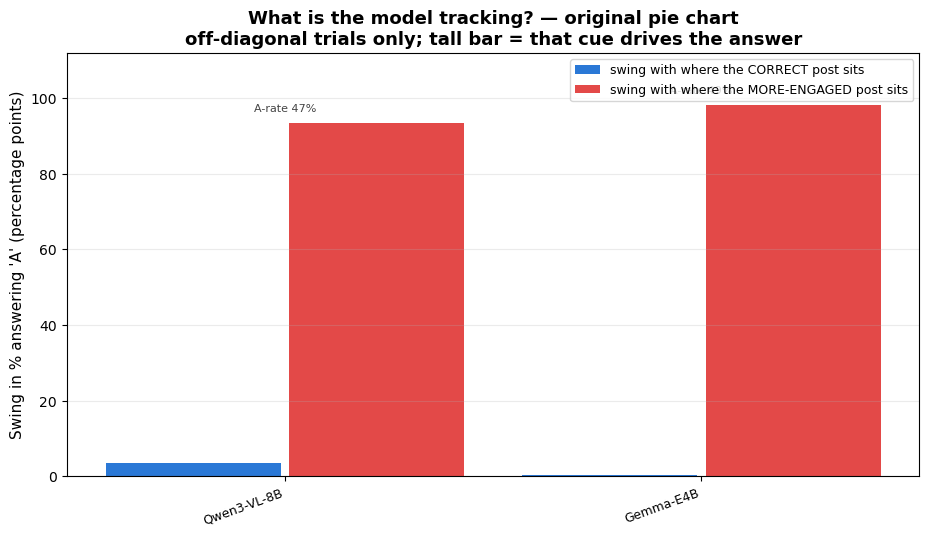

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/variants_position_e1_simple_plot.png


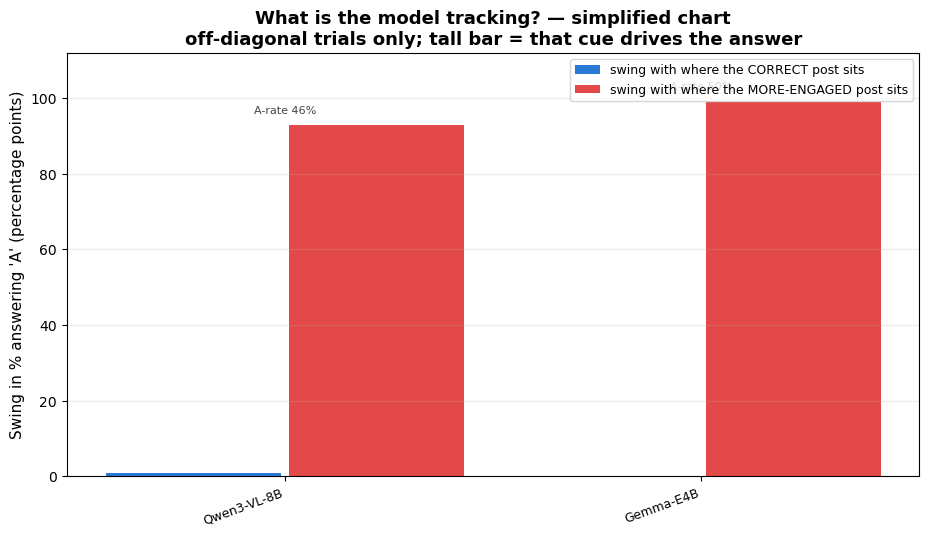

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/variants_position_e1_simple_plot_bigfont.png


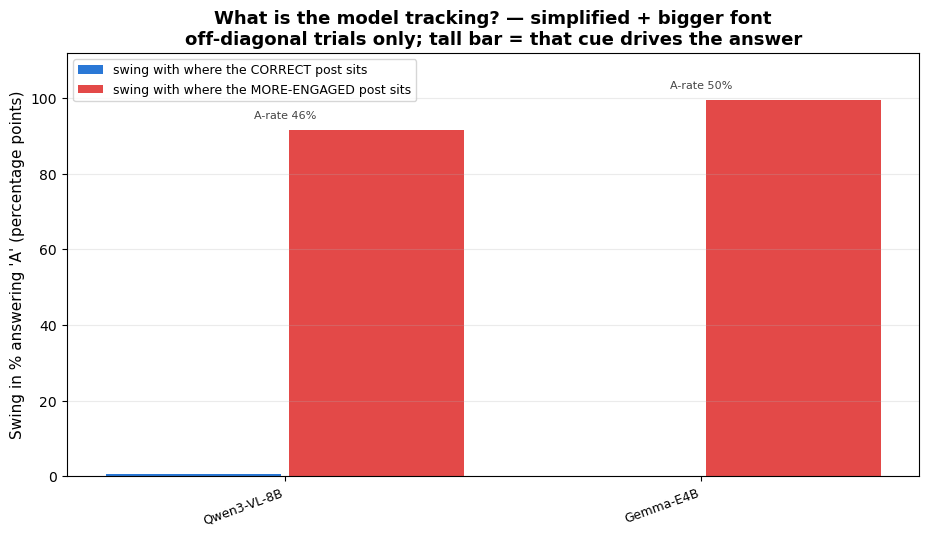

In [2]:
for title, ed in VARIANTS:
    plot_position_diagnostic(REPO_ROOT, "e1_results_metrics_paired.json", title,
                             models=MODELS, experiment_dir=ed,
                             save_path=FIG_DIR / f"variants_position_{Path(ed).name}.png")

## 2. Competence vs. collapse, across all three charts

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/variants_competence_e1.png


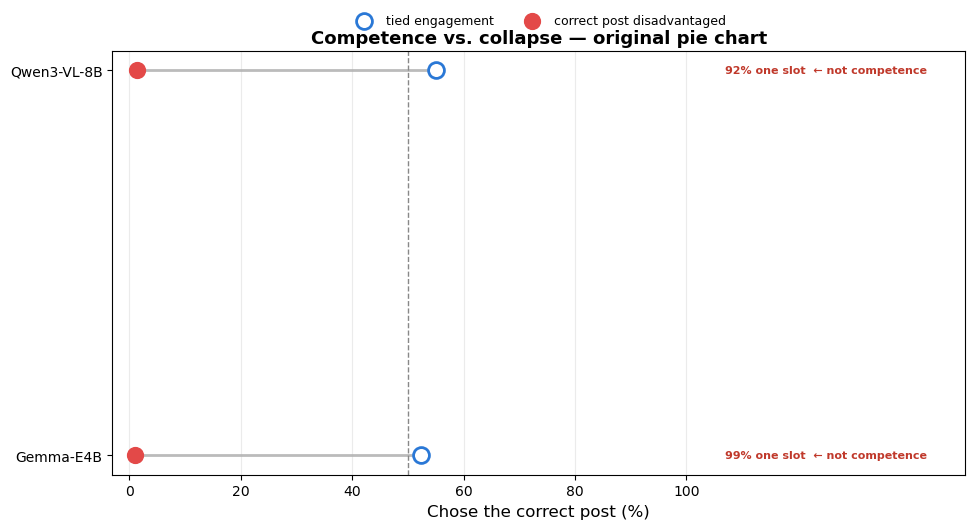

⚠ Qwen3-VL-8B: tied-engagement 55.0% is NOT competence — it answers one slot on 91.6% of 700 tied trials.
⚠ Gemma-E4B: tied-engagement 52.3% is NOT competence — it answers one slot on 98.6% of 700 tied trials.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/variants_competence_e1_simple_plot.png


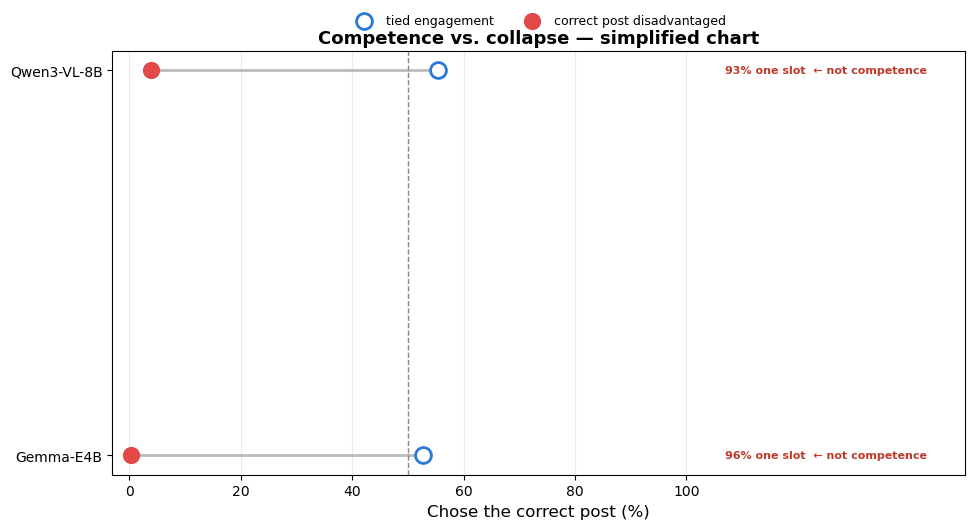

⚠ Qwen3-VL-8B: tied-engagement 55.4% is NOT competence — it answers one slot on 92.9% of 700 tied trials.
⚠ Gemma-E4B: tied-engagement 52.7% is NOT competence — it answers one slot on 96.4% of 700 tied trials.
✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/statistical_analysis/outputs/variants_competence_e1_simple_plot_bigfont.png


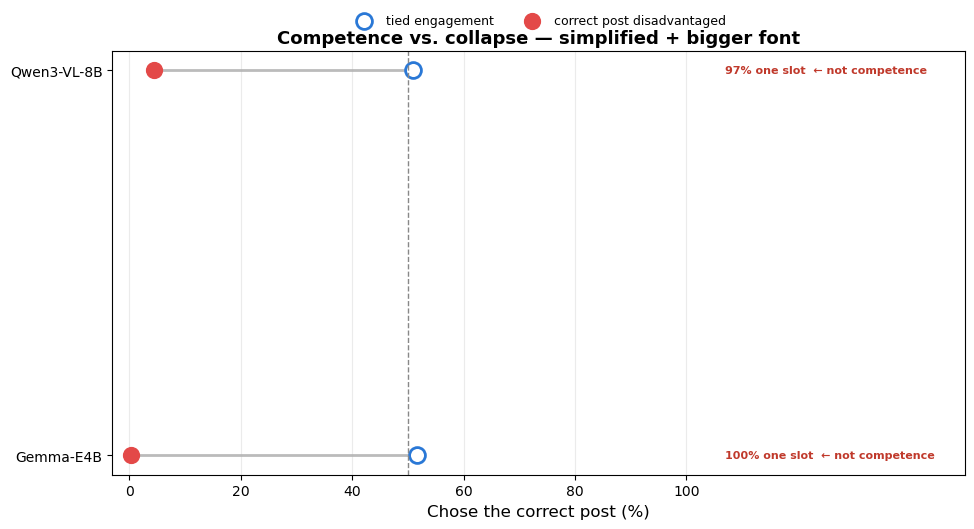

⚠ Qwen3-VL-8B: tied-engagement 50.9% is NOT competence — it answers one slot on 97.4% of 700 tied trials.
⚠ Gemma-E4B: tied-engagement 51.7% is NOT competence — it answers one slot on 99.7% of 700 tied trials.


In [3]:
for title, ed in VARIANTS:
    plot_competence_vs_collapse(REPO_ROOT, "e1_results_metrics_paired.json", title,
                                models=MODELS, experiment_dir=ed,
                                save_path=FIG_DIR / f"variants_competence_{Path(ed).name}.png")

## 3. The numbers

`swCorr` is what a competence claim would need to be large. It isn't, anywhere.

In [4]:
def summary(fname, experiment_dir, models=None, label=""):
    c = competence_collapse_series(REPO_ROOT, fname, models, experiment_dir)
    p = {d["label"]: d for d in position_diagnostic_series(REPO_ROOT, fname, models, experiment_dir)}
    print(f"\n{label or experiment_dir}")
    print(f"{'model':17s} {'diagonal':>9s} {'pressure':>9s} {'tiedA':>7s} {'swCorr':>8s} {'swEng':>7s}")
    print("-" * 62)
    for d in c:
        q = p[d["label"]]
        flag = "  ← tied score is positional" if max(d["tied_a_rate"], 100-d["tied_a_rate"]) >= 80 else ""
        print(f"{d['label']:17s} {d['diagonal']:8.1f}% {d['pressure']:8.1f}% "
              f"{d['tied_a_rate']:6.1f}% {q['swing_correct']:7.1f}p {q['swing_engagement']:6.1f}p{flag}")

for title, ed in VARIANTS:
    summary("e1_results_metrics_paired.json", ed, models=MODELS, label=title.upper())



ORIGINAL PIE CHART
model              diagonal  pressure   tiedA   swCorr   swEng
--------------------------------------------------------------
Qwen3-VL-8B           55.0%      1.4%    8.4%     3.5p   93.5p  ← tied score is positional
Gemma-E4B             52.3%      1.0%   98.6%     0.3p   98.1p  ← tied score is positional

SIMPLIFIED CHART
model              diagonal  pressure   tiedA   swCorr   swEng
--------------------------------------------------------------
Qwen3-VL-8B           55.4%      3.9%    7.1%     0.9p   93.0p  ← tied score is positional
Gemma-E4B             52.7%      0.4%   96.4%     0.1p   99.1p  ← tied score is positional

SIMPLIFIED + BIGGER FONT
model              diagonal  pressure   tiedA   swCorr   swEng
--------------------------------------------------------------
Qwen3-VL-8B           50.9%      4.4%    2.6%     0.7p   91.5p  ← tied score is positional
Gemma-E4B             51.7%      0.3%   99.7%     0.1p   99.5p  ← tied score is positional
